In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv('dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [3]:
#Exploring Transaction type
df.type.value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [9]:
type = df.type.value_counts()
transactions = type.index
quantity = type.values

import plotly.express as px

figure = px.pie(type,
            values = quantity,
            names = transactions,hole = 0.5,
            title = "Transaction Type")
figure.show()

# Hole=0.5 change pie-chart to donut chart

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [12]:
#Checking correlation between features
numeric_df = df.select_dtypes(include=['number'])
Correlation = numeric_df.corr()

In [13]:
Correlation

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


In [14]:
print(Correlation['isFraud'].sort_values(ascending=False))

isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64


In [15]:
df.drop(['oldbalanceDest','newbalanceDest'], axis=1, inplace=True)

In [16]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0,0


In [17]:
df['type'] = df['type'].map({'CASH_OUT': 0, 'PAYMENT': 1, 'TRANSFER': 2, 'DEBIT': 3, 'CASH_IN': 4, 'OTHER': 5})
df['isFraud'] = df['isFraud'].map({0: 'No Fraud', 1: 'Fraud'})

In [18]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,isFraud,isFlaggedFraud
0,1,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,No Fraud,0
1,1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,No Fraud,0
2,1,2,181.00,C1305486145,181.0,0.00,C553264065,Fraud,0
3,1,0,181.00,C840083671,181.0,0.00,C38997010,Fraud,0
4,1,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,No Fraud,0


In [19]:
# Splitting the dataset
from sklearn.model_selection import train_test_split
x = np.array(df[['type','amount','oldbalanceOrg','newbalanceOrig']])
y = np.array(df['isFraud'])

In [20]:
# Training and Testing the model
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
model.score(X_test, y_test)


0.9997320286297154

              precision    recall  f1-score   support

       Fraud       0.90      0.89      0.89      1620
    No Fraud       1.00      1.00      1.00   1270904

    accuracy                           1.00   1272524
   macro avg       0.95      0.95      0.95   1272524
weighted avg       1.00      1.00      1.00   1272524

[[   1446     174]
 [    167 1270737]]


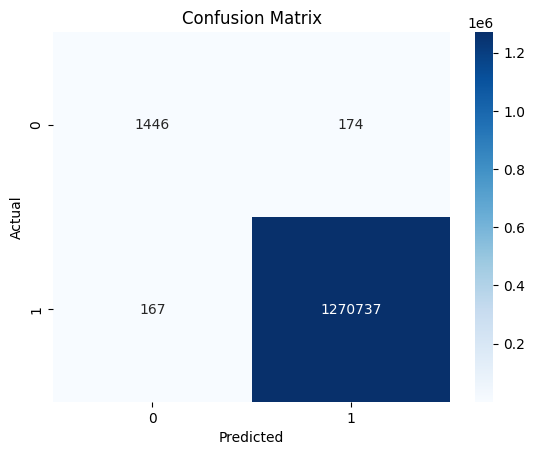

In [21]:
#Prediction
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))    
print(confusion_matrix(y_test, y_pred))
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()